In [23]:
import numpy as np
import networkx as nx
import torch

import sys
sys.path.append('../')
from models.staged import STAGED
from utils.graph_constructor import GraphConstructor
from tests.test_graph_constructor import create_square_grid_data as create_test_data
from utils.visualization import visualize_attention_graph, visualize_graph

In [24]:
data = create_test_data()

In [25]:
data.keys()

dict_keys(['gene_expression', 'cell_positions', 'genes', 'cell_type_assignments', 'ligand_receptor_pairs', 'receptor_gene_pairs', 'prior_grns', 'n_time_points', 'n_cells', 'n_genes'])

In [26]:
for key, value in data.items():
    if isinstance(value, (torch.Tensor, np.ndarray)):
        print(f"{key}: {value.shape}")
    elif isinstance(value, (list, dict)):
        print(f"{key}: length {len(value)}")
    else:
        print(f"{key}: {value}")

gene_expression: torch.Size([15, 4, 6])
cell_positions: torch.Size([15, 4, 2])
genes: length 6
cell_type_assignments: torch.Size([4])
ligand_receptor_pairs: length 2
receptor_gene_pairs: length 8
prior_grns: length 2
n_time_points: 15
n_cells: 4
n_genes: 6


In [27]:
data['genes']

['gene_0', 'gene_1', 'gene_2', 'gene_3', 'gene_4', 'gene_5']

In [28]:
data['ligand_receptor_pairs']

[('gene_0', 'gene_1'), ('gene_2', 'gene_3')]

In [29]:
data['cell_type_assignments']

tensor([0, 0, 1, 1])

In [30]:
graph_constructor = GraphConstructor(
    genes=data['genes'],
    ligand_receptor_pairs=data['ligand_receptor_pairs'],
    receptor_gene_pairs=data['receptor_gene_pairs'],
    cell_type_assignments=data['cell_type_assignments'],
    prior_grns=data['prior_grns']
)

# Define time lags as specified by the user
delta_gl = 1  # Time lag for gene -> ligand
delta_lr = 5  # Time lag for ligand -> receptor
delta_rg = 3  # Time lag for receptor -> gene
delta_gg = 7  # Time lag for gene -> gene

time_point = 10

# Ensure time_point is large enough to handle the lags
max_lag = max(delta_gl, delta_lr, delta_rg, delta_gg)
if time_point < max_lag:
    time_point = max_lag
    print(f"Adjusted time_point to {time_point} to handle time lags")


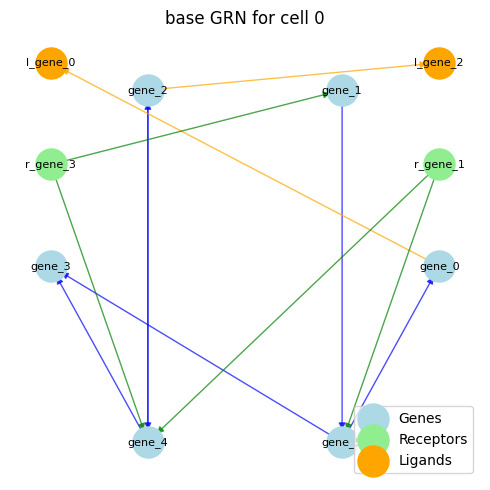

In [31]:
cell_idx = 0
base_graph = graph_constructor.construct_base_graph(cell_idx)
visualize_graph(base_graph, f"base GRN for cell {cell_idx}", save_plot=False, show_plot=True, figsize=(5, 5))

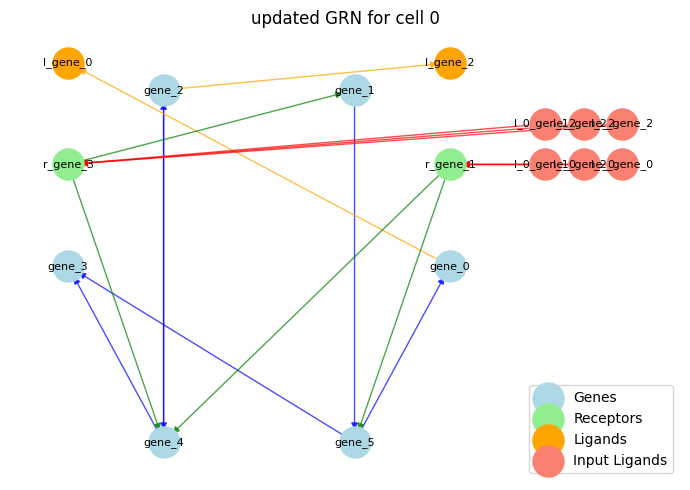

In [32]:
distance_threshold = 10
updated_graph = graph_constructor.update_graph_with_neighbors(
    base_graph, cell_idx, data['cell_positions'], time_point,
    distance_threshold=distance_threshold
)
pos = visualize_graph(updated_graph, f"updated GRN for cell {cell_idx}", save_plot=False, show_plot=True, figsize=(7, 5), return_pos=True)


In [33]:
pyg_graph = graph_constructor.assign_node_features(
    updated_graph, cell_idx, time_point, data['gene_expression'],
    delta_gl, delta_lr, delta_rg, delta_gg
)

In [34]:
pyg_graph

Data(x=[16, 1], edge_index=[2, 18], gene_node_indices=[6], node_names=[16], node_types=[16])

In [35]:
pyg_graph.gene_node_indices

[0, 1, 2, 3, 4, 5]

In [36]:
updated_graph.nodes()

NodeView(('gene_0', 'gene_1', 'gene_2', 'gene_3', 'gene_4', 'gene_5', 'r_gene_1', 'r_gene_3', 'l_gene_2', 'l_gene_0', 'l_0_gene_0', 'l_0_gene_2', 'l_1_gene_0', 'l_1_gene_2', 'l_2_gene_0', 'l_2_gene_2'))

In [37]:
model = STAGED(
    num_genes=len(data['genes']),
    hidden_dim=64,
    num_gat_layers=1,
    num_mlp_layers=3,
    dropout=0.1,
    delta_gl=delta_gl,  # Time lag for gene -> ligand
    delta_lr=delta_lr,  # Time lag for ligand -> receptor 
    delta_rg=delta_rg,  # Time lag for receptor -> gene
    delta_gg=delta_gg,  # Time lag for gene -> gene
    add_self_loops=False,
)

In [38]:
node_embeddings, (edge_index, attention_weights) = model(pyg_graph)

In [39]:
node_embeddings.shape

torch.Size([16, 64])

In [40]:
edge_index.shape

torch.Size([2, 18])

In [41]:
attention_weights.shape

torch.Size([18, 1])

In [42]:
pyg_graph

Data(x=[16, 1], edge_index=[2, 18], gene_node_indices=[6], node_names=[16], node_types=[16])

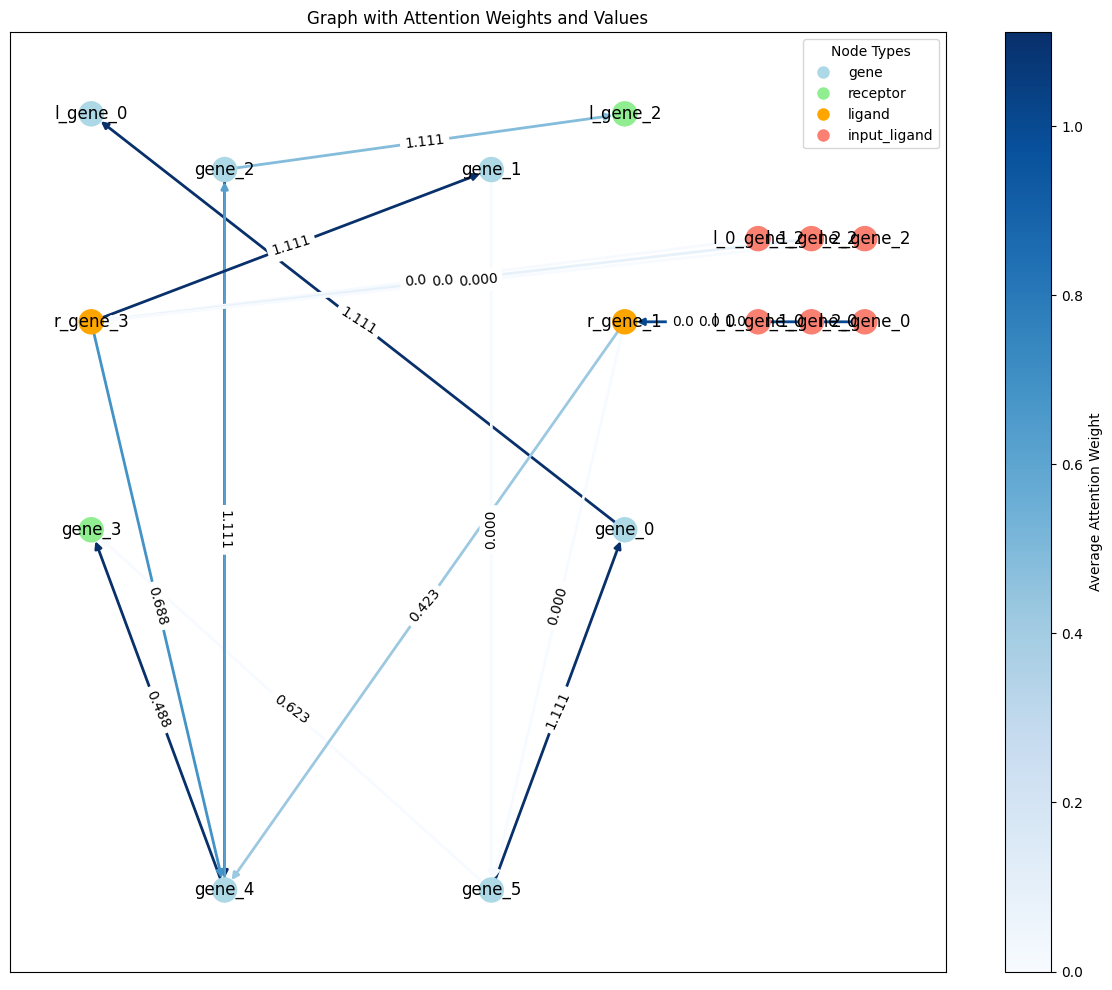

In [43]:
visualize_attention_graph(pyg_graph, edge_index, attention_weights, pos)

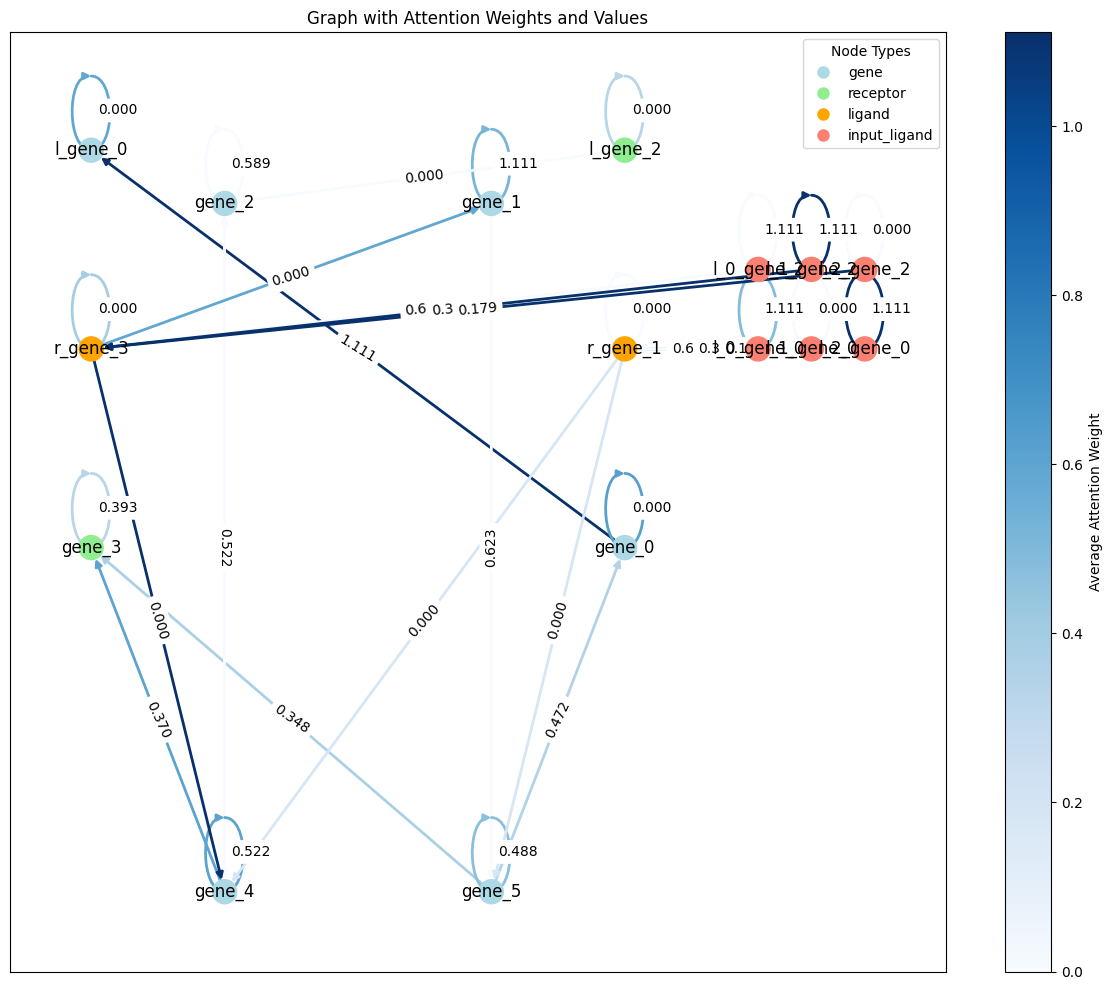

In [44]:
model = STAGED(
    num_genes=len(data['genes']),
    hidden_dim=64,
    num_gat_layers=1,
    num_mlp_layers=3,
    dropout=0.1,
    delta_gl=delta_gl,  # Time lag for gene -> ligand
    delta_lr=delta_lr,  # Time lag for ligand -> receptor 
    delta_rg=delta_rg,  # Time lag for receptor -> gene
    delta_gg=delta_gg,  # Time lag for gene -> gene
    add_self_loops=True,
)

node_embeddings, (edge_index, attention_weights) = model(pyg_graph)
visualize_attention_graph(pyg_graph, edge_index, attention_weights, pos)